# Practice with four virtual CPU devices

Start a fresh kernel, then Run all: the first cell configures 4 logical CPU devices before backend initialization. They share one physical CPU; this is sharding practice, not TPU performance emulation. TPU execution not validated.

- Start four virtual CPU devices in a fresh process.
- Explain global shape, shard index and local shape.
- Compare row partitioning with replication.
- Diagnose divisibility and distinguish CPU practice from TPU evidence.

You can explore how JAX splits an array across devices using just your laptop. We’ll create four logical CPU devices, give each one a piece of an array, and compare the result with NumPy. Start with the setup and array/device lessons. These logical devices share your CPU: they help us learn placement, but they do not reproduce accelerator speed or memory.

## The idea

Virtual CPU devices let one Python process exercise JAX placement APIs without renting an accelerator. The devices are logical execution targets backed by the same host. You can practice global shapes, local shards, replicated inputs and shape constraints. They do not reproduce TPU memory, interconnect bandwidth, accelerator instructions, multi-host failures or performance.

## Configure the runtime before it exists

Open the lesson workspace from setup and create main.py. The first block imports JAX, chooses CPU, and requests four CPU devices. Importing jax is allowed before the configuration; querying devices or creating an array can initialize the backend. That initialization is the boundary after which changing the count is too late.

Run python main.py as a fresh process. In Jupyter or Colab, restart the kernel/runtime and use Run all so this configuration is the first JAX operation. If you already ran an earlier lesson in that kernel, merely rerunning this cell cannot reliably rebuild the runtime. The explicit count check gives you a repair instruction instead of silently proceeding with one device. A terminal alternative is `JAX_PLATFORMS=cpu JAX_NUM_CPU_DEVICES=4 python main.py`; Windows PowerShell uses `$env:JAX_PLATFORMS="cpu"` and `$env:JAX_NUM_CPU_DEVICES="4"` before python main.py.

## Distinguish logical devices from your CPU hardware

Four reported CPU devices do not mean you bought four CPUs or reserved four isolated cores. They share your computer and its resources. Each is a target JAX can place an array on. Keep the actual JAX version, device platform, process count and device count in your report so readers know what was tested.

This exercise has one controller process and four addressable devices. Multi-host JAX involves additional processes and coordination; this exercise does not test those. Even if you time an operation here, the observation belongs to this CPU setup and workload. It cannot establish whether the same partitioning is fast on a TPU.

## A global array contains local pieces

The host array has shape $(4,2)$: four examples with two values each. Mesh assigns the four devices the named axis data. `P("data",None)` maps the first array dimension to that mesh axis and leaves the feature dimension unpartitioned. Each local shard therefore has shape $(1,2)$.

Use shard.index to identify its slice in the global array and shard.data to inspect its values. The global x.shape stays $(4,2)$; it does not become $(1,2)$ just because each device holds one row. Conversion with `np.asarray(x)` gathers the fully addressable global array to the host in this small single-process exercise.

```text
Global rows [0,1] [2,3] [4,5] [6,7]
             ↓     ↓     ↓     ↓
CPU device   0     1     2     3
local shape (1,2) on every device; global shape (4,2)
```

## Check arithmetic separately from placement

The function $2x+1$ is elementwise: a row does not need a value from a different row. For the first row $[0,1]$, predict $[1,3]$; for the final row $[6,7]$, predict $[13,15]$. The jit contract declares input and output placement explicitly. The NumPy check verifies all values, and shard inspections verify the intended partition. Neither alone verifies both.

block_until_ready waits for the result before reporting. It is useful when observing execution and essential for a future synchronized timing experiment, but no timings are claimed here. Four-way row partitioning requires a row count divisible by four. Try five rows deliberately, read the shape error, and choose a repair that preserves what your experiment means.

## Start a fresh CPU runtime

Create main.py in your course workspace. Paste this block first. If using a notebook, restart its kernel before running any cell.

In [1]:
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_num_cpu_devices", 4)
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
devices = jax.devices("cpu")
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
mesh = Mesh(np.array(devices), ("data",))
rows = NamedSharding(mesh, P("data", None))
replicated = NamedSharding(mesh, P())

Configuration happens before `devices()` or array creation initializes a backend. This file explicitly chooses CPU even on a GPU machine.

## Place and compute

Append this block in the same file. Predict the shapes and values before running.

In [2]:
host = np.arange(8, dtype=np.float32).reshape(4, 2)
x = jax.device_put(host, rows)
y = jax.jit(lambda a: 2 * a + 1, in_shardings=rows, out_shardings=rows)(x)
y.block_until_ready()

Mesh axis names describe placement. They are separate from the numerical array dimensions.

## Inspect and verify

Append the checks, save the file and run python main.py with the setup lesson environment.

In [3]:
print("JAX version:", jax.__version__)
print("CPU devices:", len(devices))
for shard in x.addressable_shards:
    print("Device", shard.device.id, "index", shard.index, "values", np.asarray(shard.data))
np.testing.assert_array_equal(np.asarray(y), 2 * host + 1)
assert len(x.addressable_shards) == 4
assert all(shard.data.shape == (1, 2) for shard in x.addressable_shards)
print("Global shape:", x.shape, "result:", np.asarray(y).tolist())

JAX version: 0.9.2
CPU devices: 4
Device 0 index (slice(0, 1, None), slice(None, None, None)) values [[0. 1.]]
Device 1 index (slice(1, 2, None), slice(None, None, None)) values [[2. 3.]]
Device 2 index (slice(2, 3, None), slice(None, None, None)) values [[4. 5.]]
Device 3 index (slice(3, 4, None), slice(None, None, None)) values [[6. 7.]]
Global shape: (4, 2) result: [[1.0, 3.0], [5.0, 7.0], [9.0, 11.0], [13.0, 15.0]]


Assertions compare against host calculations or hand-derived values; printing a sharding object alone does not establish correctness.

## Run the example

In [4]:
import jax
# Run this file in a fresh process; in a notebook restart the kernel first.
jax.config.update("jax_platforms", "cpu")
jax.config.update("jax_num_cpu_devices", 4)
import jax.numpy as jnp
import numpy as np
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
devices = jax.devices("cpu")
if len(devices) != 4:
    raise RuntimeError("Expected four CPU devices. Restart the notebook kernel, then Run all; do not run an earlier JAX cell first.")
mesh = Mesh(np.array(devices), ("data",))
rows = NamedSharding(mesh, P("data", None))
replicated = NamedSharding(mesh, P())

host = np.arange(8, dtype=np.float32).reshape(4, 2)
x = jax.device_put(host, rows)
y = jax.jit(lambda a: 2 * a + 1, in_shardings=rows, out_shardings=rows)(x)
y.block_until_ready()

print("JAX version:", jax.__version__)
print("CPU devices:", len(devices))
for shard in x.addressable_shards:
    print("Device", shard.device.id, "index", shard.index, "values", np.asarray(shard.data))
np.testing.assert_array_equal(np.asarray(y), 2 * host + 1)
assert len(x.addressable_shards) == 4
assert all(shard.data.shape == (1, 2) for shard in x.addressable_shards)
print("Global shape:", x.shape, "result:", np.asarray(y).tolist())

JAX version: 0.9.2
CPU devices: 4
Device 0 index (slice(0, 1, None), slice(None, None, None)) values [[0. 1.]]
Device 1 index (slice(1, 2, None), slice(None, None, None)) values [[2. 3.]]
Device 2 index (slice(2, 3, None), slice(None, None, None)) values [[4. 5.]]
Device 3 index (slice(3, 4, None), slice(None, None, None)) values [[6. 7.]]
Global shape: (4, 2) result: [[1.0, 3.0], [5.0, 7.0], [9.0, 11.0], [13.0, 15.0]]


Expected: CPU devices: $4$. Four input shards of shape $(1,2)$. Global shape $(4,2)$; result $[[1,3]$,$[5,7]$,$[9,11]$,$[13,15]]$. Device repr and JAX version vary.

## Four logical devices own four different rows

Predict: Does each device hold the full array or one row?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
owners = np.empty(host.shape, dtype=int)
for s in x.addressable_shards:
    owners[s.index] = s.device.id
visual_data = {'kind': 'heatmap', 'values': owners.tolist(), 'unit': 'logical CPU device ID', 'rows': ['row ' + str(i) for i in range(4)], 'columns': ['feature 0', 'feature 1']}

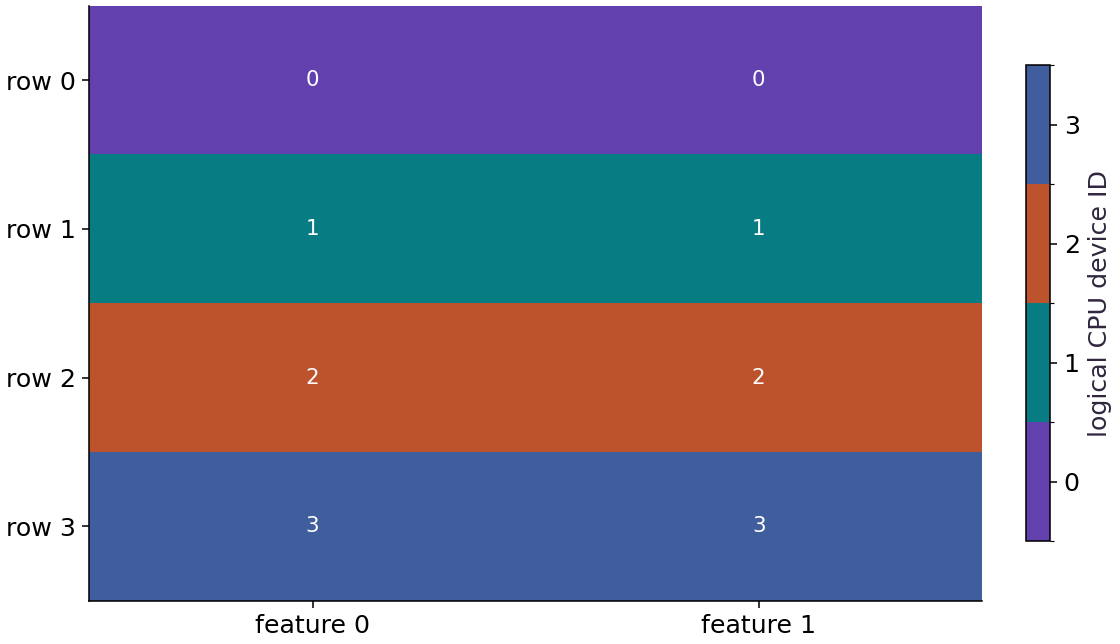

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each cell represents a position in the global array, and its number identifies the logical CPU device that owns that position. The colors are categories: device $3$ is not “more powerful” than device $0$.

Both cells in row $0$ belong to device $0$; both cells in row $1$ belong to device $1$, and the same pattern continues through row $3$. Horizontal bands show that this layout partitions rows while keeping each row’s features together.

### Connect it to the computation

The global shape is $(4,2)$, so splitting its first axis across four devices gives each device a local piece with shape $(1,2)$. This is the spatial meaning of the row partition in the code. The numbers in the figure are ownership labels, not the original array’s contents.

You can check the interpretation by locating row $2$, feature $1$: its owner is device $2$. These logical devices share the host CPU. The figure establishes where values are placed, not a measured speedup or the behavior of four physical accelerators.

## Keep the shape, change the values

Predict: If every input value becomes negative, do the number of devices or local shard shapes change?

In [7]:
negative = -host - 2
negative_x = jax.device_put(negative, rows)
negative_y = jax.jit(lambda a: 2*a+1, in_shardings=rows, out_shardings=rows)(negative_x)
np.testing.assert_array_equal(np.asarray(negative_y), 2*negative+1)
assert all(s.data.shape == (1,2) for s in negative_x.addressable_shards)
print("Negative input result:", np.asarray(negative_y).tolist())

Negative input result: [[-3.0, -5.0], [-7.0, -9.0], [-11.0, -13.0], [-15.0, -17.0]]


Expected: Result $[[-3,-5]$,$[-7,-9]$,$[-11,-13]$,$[-15,-17]]$; local shapes remain $(1,2)$.

Placement follows the declared shape/specification, not the signs or magnitudes of array elements.

## Replicate instead of partitioning

Predict: With `P()`, which values should each CPU device receive?

In [8]:
copies = jax.device_put(host, replicated)
assert copies.is_fully_replicated
assert len(copies.addressable_shards) == 4
for shard in copies.addressable_shards:
    np.testing.assert_array_equal(np.asarray(shard.data), host)
print("Replicated local shapes:", [s.data.shape for s in copies.addressable_shards])

Replicated local shapes: [(4, 2), (4, 2), (4, 2), (4, 2)]


Expected: Four local arrays of shape $(4,2)$, each containing the entire input.

Replication stores full copies. A global array shape alone cannot tell you how much of it lives on each device.

## Your exercise

Predict and verify the per-device shapes for twelve rows, then demonstrate how replication repairs an indivisible five-row placement without deleting data.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
twelve = np.arange(24,dtype=np.float32).reshape(12,2)
z = jax.device_put(twelve, rows)
z2 = jax.jit(lambda a:a*a, in_shardings=rows, out_shardings=rows)(z)
assert all(s.data.shape == (3,2) for s in z2.addressable_shards)
for shard in z2.addressable_shards:
    np.testing.assert_array_equal(np.asarray(shard.data), (twelve*twelve)[shard.index])

uneven = np.arange(10,dtype=np.float32).reshape(5,2)
try:
    jax.device_put(uneven, rows)
except ValueError:
    print("Expected indivisible row dimension")
else:
    raise AssertionError("Expected divisibility failure")
fixed = jax.device_put(uneven, replicated)
np.testing.assert_array_equal(np.asarray(fixed), uneven)
assert fixed.is_fully_replicated

Expected indivisible row dimension


## Move from four rows to twelve · Challenge

Create twelve two-feature rows with values $0$ through $23$. Predict shard shape and check every slice of a squared output.

Hint: Use each shard index to select the corresponding NumPy reference slice.

In [11]:
# Write your attempt here.

## Reference reasoning

The twelve rows split into four groups of three. Index-based comparisons establish that the right values occupy each piece, rather than checking only a total.

In [12]:
twelve = np.arange(24,dtype=np.float32).reshape(12,2)
z = jax.device_put(twelve, rows)
z2 = jax.jit(lambda a:a*a, in_shardings=rows, out_shardings=rows)(z)
assert all(s.data.shape == (3,2) for s in z2.addressable_shards)
for shard in z2.addressable_shards:
    np.testing.assert_array_equal(np.asarray(shard.data), (twelve*twelve)[shard.index])

## Repair a batch that does not divide evenly · Challenge

Place a $(5,2)$ array with the same row sharding. Capture the failure. Repair this placement demonstration by replicating it, and explain why that does not prove the partitioned algorithm supports uneven batches.

Hint: Do not drop a row to hide the error.

In [13]:
# Write your attempt here.

## Reference reasoning

Five rows cannot be evenly split across the four-way data axis. Replication preserves all observations but changes the memory/communication plan; padding requires a mask when computing means.

In [14]:
uneven = np.arange(10,dtype=np.float32).reshape(5,2)
try:
    jax.device_put(uneven, rows)
except ValueError:
    print("Expected indivisible row dimension")
else:
    raise AssertionError("Expected divisibility failure")
fixed = jax.device_put(uneven, replicated)
np.testing.assert_array_equal(np.asarray(fixed), uneven)
assert fixed.is_fully_replicated

Expected indivisible row dimension


## Checkpoint

What does a $(12,2)$ global array sharded with `P("data",None)` over four devices mean?

1. Each device holds a $(3,2)$ slice and the global array remains $(12,2)$.
2. Each device holds the complete array.
3. Each device represents a separate TPU chip.

## Diagnose

Five rows cannot be evenly split across the four-way data axis. Replication preserves all observations but changes the memory/communication plan; padding requires a mask when computing means.

## Evidence

Keep package/device reports, global and local shapes, shard index/value tables, NumPy comparisons, changed-shape predictions, and the five-row failure/repair. State that the run uses one host and does not validate TPU performance.

## Carry forward

- Configure the runtime before it exists
- Distinguish logical devices from your CPU hardware
- A global array contains local pieces
- Check arithmetic separately from placement

## Primary references

- [JAX CPU device configuration (set before initialization)](https://docs.jax.dev/en/latest/config_options.html#num-cpu-devices)
- [Distributed arrays and automatic parallelization](https://docs.jax.dev/en/latest/201/sharding.html)